# S11-27 — Feature Importance Monitoring — Scénario by_location

| Champ | Valeur |
|-------|--------|
| **Expériences** | exp_116 (KMeans), exp_117 (Mahalanobis), exp_118 (EWC), exp_119 (HDC) |
| **Scénario** | by_location : 5 sites géographiques (tâches CL) |
| **Features** | 4 features : temperature, pressure, vibration, humidity |
| **Sprint** | Sprint 11 — S11-27 |

> **Pré-requis** : lancer S11-25 avant d'exécuter ce notebook :
> ```bash
> python scripts/train_kmeans.py --config configs/monitoring_by_location_config.yaml  # exp_116
> python scripts/train_mahalanobis.py --config configs/monitoring_by_location_config.yaml  # exp_117
> python scripts/train_ewc.py --config configs/monitoring_by_location_config.yaml  # exp_118
> python scripts/train_hdc.py --config configs/monitoring_by_location_config.yaml  # exp_119
> ```

## Section 1 — Setup, imports et chargement des résultats

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Image

_cwd = Path('.').resolve()
if _cwd.name == 'monitoring_feature_importance':
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == 'cl_eval':
    os.chdir(_cwd.parent.parent)

sys.path.insert(0, str(Path('.').resolve()))

from src.evaluation.feature_importance import (
    FEATURE_NAMES_MONITORING,
    plot_feature_importance,
    plot_feature_importance_comparison,
)

FIGURES_DIR = Path("notebooks/figures/cl_evaluation/monitoring_feature_importance")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPS = {
    "KMeans":      "experiments/exp_116_kmeans_monitoring_by_location/results/feature_importance.json",
    "Mahalanobis": "experiments/exp_117_mahalanobis_monitoring_by_location/results/feature_importance.json",
    "EWC":         "experiments/exp_118_ewc_monitoring_by_location/results/feature_importance.json",
    "HDC":         "experiments/exp_119_hdc_monitoring_by_location/results/feature_importance.json",
}

data = {model: json.load(open(path)) for model, path in EXPS.items()}

# Les noms de tâches sont déterminés dynamiquement depuis les JSONs
TASKS = list(data["EWC"]["per_task"].keys())
print("Chargement OK — modèles :", list(data.keys()))
print("Features :", FEATURE_NAMES_MONITORING)
print("Tâches (locations) :", TASKS)

Chargement OK — modèles : ['KMeans', 'Mahalanobis', 'EWC', 'HDC']
Features : ['temperature', 'pressure', 'vibration', 'humidity']
Tâches (locations) : ['Atlanta', 'Chicago', 'Houston', 'New York', 'San Francisco']


## Section 2 — Tableau récapitulatif global (ranking par modèle)

In [2]:
rows = {}
for model, d in data.items():
    scores = d["global"]["permutation_importance"]
    rows[model] = {f: scores.get(f, 0.0) for f in FEATURE_NAMES_MONITORING}

df = pd.DataFrame(rows).T
df_rank = df.rank(axis=1, ascending=False).astype(int)

print("=== Scores d'importance (permutation globale) ===")
display(df.round(4))
print()
print("=== Rang par feature (1 = plus importante) ===")
display(df_rank)

=== Scores d'importance (permutation globale) ===


,temperature,pressure,vibration,humidity
KMeans,0.0285,0.0180,0.0108,0.0116
Mahalanobis,0.0345,0.0074,0.0219,0.0052
EWC,0.0734,0.0212,0.0376,0.0060
HDC,0.0547,0.0236,0.0304,0.0154



=== Rang par feature (1 = plus importante) ===


,temperature,pressure,vibration,humidity
KMeans,1,2,4,3
Mahalanobis,1,3,2,4
EWC,1,3,2,4
HDC,1,3,2,4


## Section 3 — Barplot groupé global (4 modèles × 4 features)

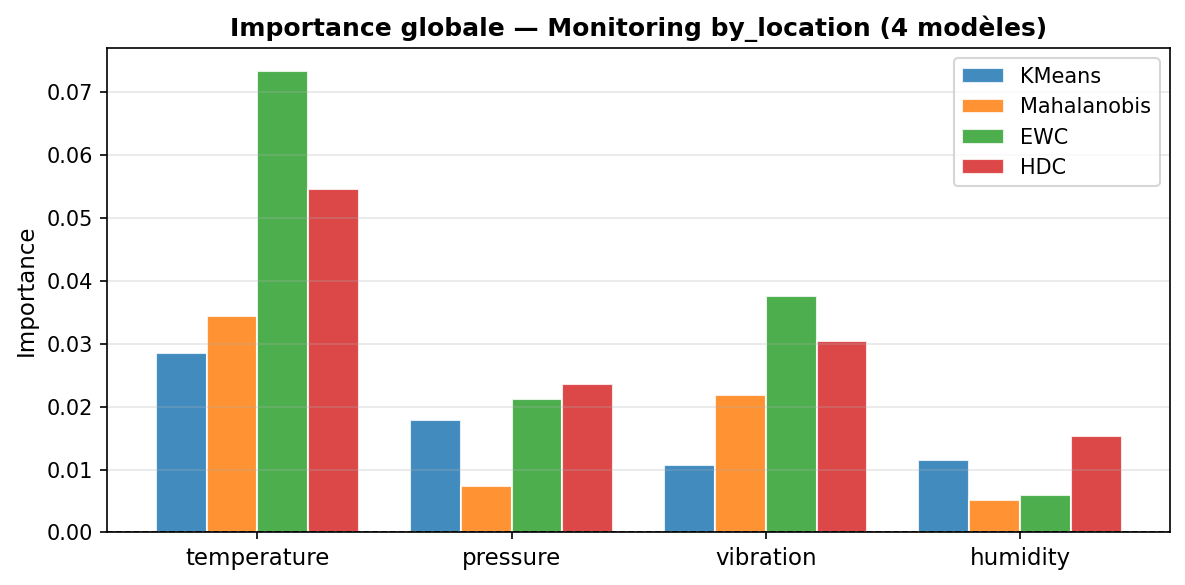

Figure sauvegardée : notebooks/figures/cl_evaluation/monitoring_feature_importance/by_location_global_comparison.png


In [3]:
importances_dict = {
    model: d["global"]["permutation_importance"]
    for model, d in data.items()
}

fig = plot_feature_importance_comparison(
    importances_dict,
    FEATURE_NAMES_MONITORING,
    title="Importance globale — Monitoring by_location (4 modèles)",
)
fig.savefig(FIGURES_DIR / "by_location_global_comparison.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_location_global_comparison.png")))
print(f"Figure sauvegardée : {FIGURES_DIR / 'by_location_global_comparison.png'}")

## Section 4 — Heatmap per-task (5 locations × 4 features) par modèle

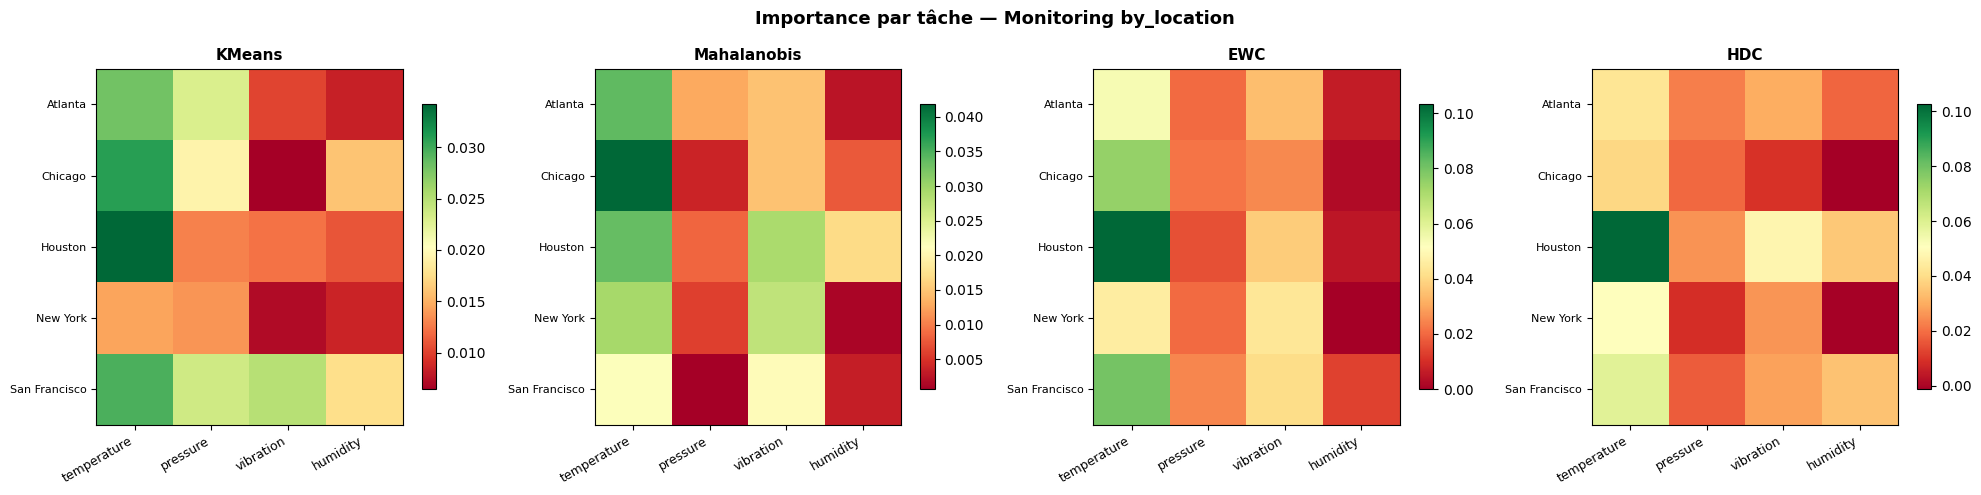

Figure sauvegardée : notebooks/figures/cl_evaluation/monitoring_feature_importance/by_location_per_task_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Importance par tâche — Monitoring by_location", fontsize=13, fontweight="bold")

for ax, (model, d) in zip(axes, data.items()):
    mat = np.array([
        [d["per_task"][t]["permutation_importance"].get(f, 0.0) for f in FEATURE_NAMES_MONITORING]
        for t in TASKS
    ])
    im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=mat.min(), vmax=max(abs(mat).max(), 1e-6))
    ax.set_xticks(range(len(FEATURE_NAMES_MONITORING)))
    ax.set_xticklabels(FEATURE_NAMES_MONITORING, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(TASKS)))
    ax.set_yticklabels(TASKS, fontsize=8)
    ax.set_title(model, fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "by_location_per_task_heatmap.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_location_per_task_heatmap.png")))
print(f"Figure sauvegardée : {FIGURES_DIR / 'by_location_per_task_heatmap.png'}")

## Section 5 — EWC : permutation vs gradient saliency (normalisés)

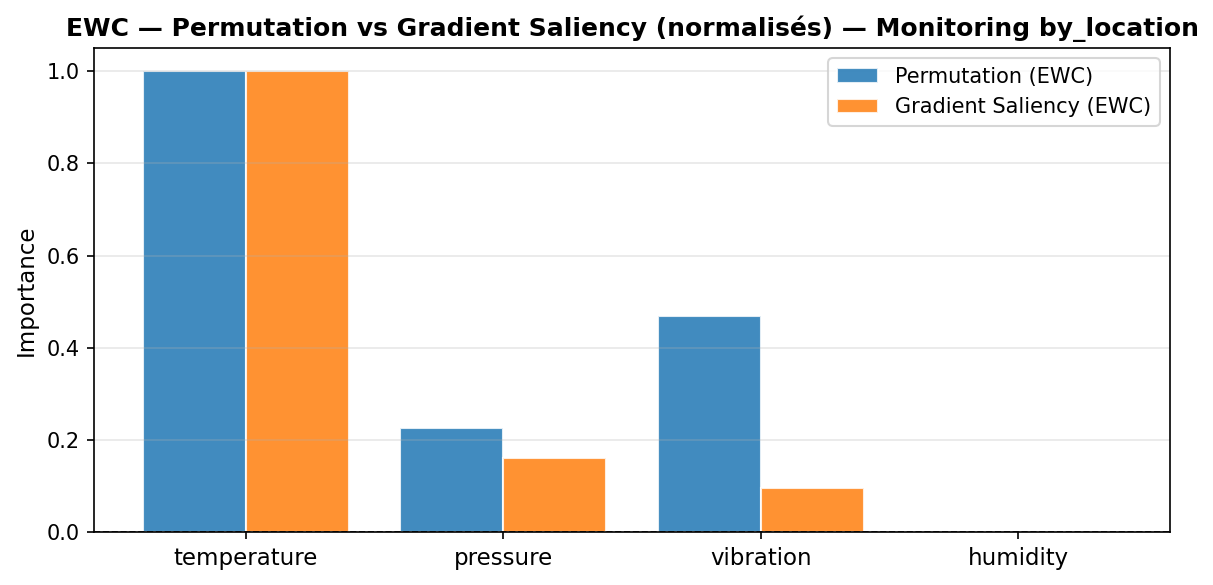

Corrélation de Spearman entre les deux méthodes : ρ = 0.800  (p = 0.200)


In [5]:
from scipy.stats import spearmanr

ewc = data["EWC"]["global"]
perm = ewc["permutation_importance"]
grad = ewc["gradient_saliency"]

def minmax(d):
    vals = np.array(list(d.values()))
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 0.0 for k in d}
    return {k: (v - mn) / (mx - mn) for k, v in d.items()}

perm_n = minmax(perm)
grad_n = minmax(grad)

importances_ewc = {"Permutation (EWC)": perm_n, "Gradient Saliency (EWC)": grad_n}
fig = plot_feature_importance_comparison(
    importances_ewc,
    FEATURE_NAMES_MONITORING,
    title="EWC — Permutation vs Gradient Saliency (normalisés) — Monitoring by_location",
)
fig.savefig(FIGURES_DIR / "by_location_ewc_perm_vs_grad.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_location_ewc_perm_vs_grad.png")))

rho, p = spearmanr(
    [perm_n[f] for f in FEATURE_NAMES_MONITORING],
    [grad_n[f] for f in FEATURE_NAMES_MONITORING],
)
print(f"Corrélation de Spearman entre les deux méthodes : ρ = {rho:.3f}  (p = {p:.3f})")

## Section 6 — HDC : permutation vs feature masking

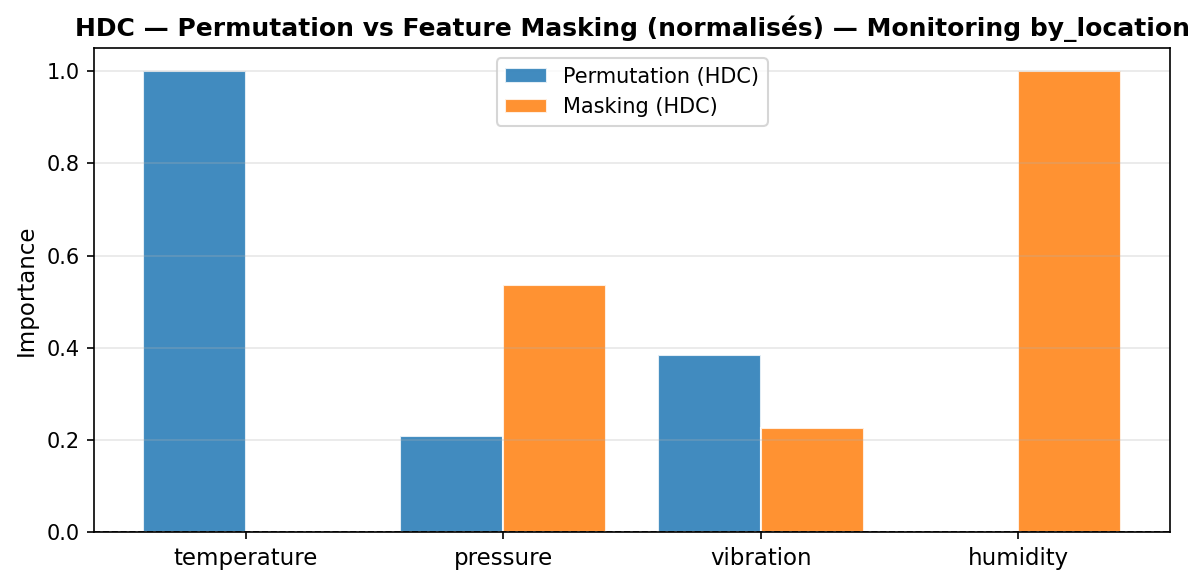

Corrélation Spearman Permutation/Masking (HDC) : ρ = -1.000  (p = 0.000)


In [6]:
hdc = data["HDC"]["global"]
perm_h = hdc["permutation_importance"]
mask_h = hdc["feature_masking_importance"]

perm_h_n = minmax(perm_h)
mask_h_n = minmax(mask_h)

importances_hdc = {"Permutation (HDC)": perm_h_n, "Masking (HDC)": mask_h_n}
fig = plot_feature_importance_comparison(
    importances_hdc,
    FEATURE_NAMES_MONITORING,
    title="HDC — Permutation vs Feature Masking (normalisés) — Monitoring by_location",
)
fig.savefig(FIGURES_DIR / "by_location_hdc_perm_vs_masking.png", bbox_inches="tight")
display(Image(str(FIGURES_DIR / "by_location_hdc_perm_vs_masking.png")))

rho, p = spearmanr(
    [perm_h_n[f] for f in FEATURE_NAMES_MONITORING],
    [mask_h_n[f] for f in FEATURE_NAMES_MONITORING],
)
print(f"Corrélation Spearman Permutation/Masking (HDC) : ρ = {rho:.3f}  (p = {p:.3f})")

## Section 7 — Comparaison by_equipment vs by_location

Question clé : **les mêmes features sont-elles importantes indépendamment du découpage CL ?**

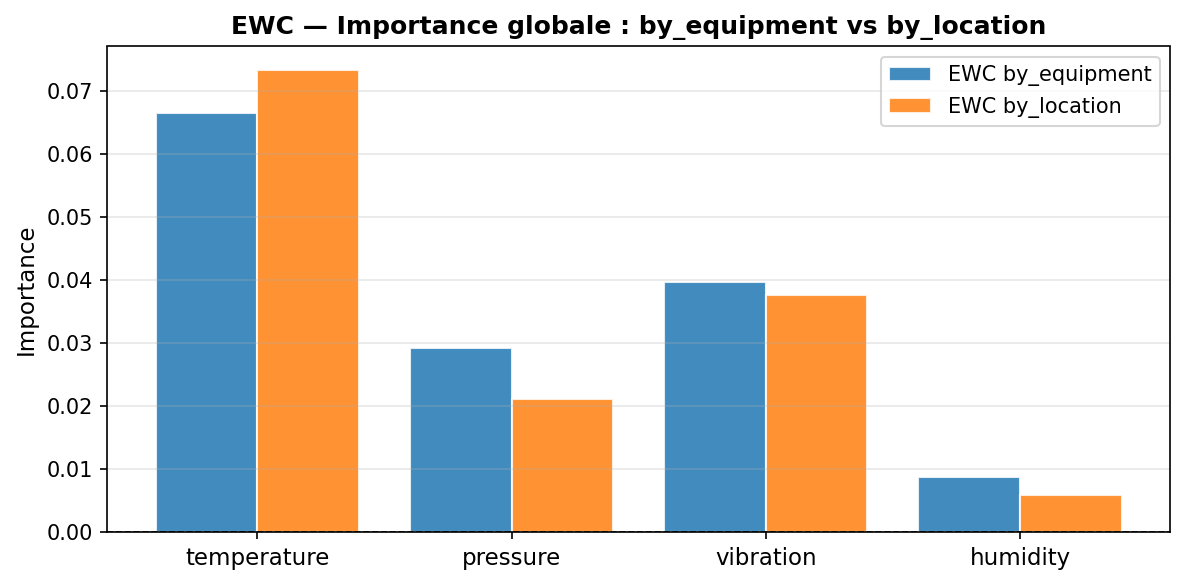

Corrélation Spearman by_equipment / by_location (EWC) : ρ = 1.000  (p = 0.000)
ρ ≈ 1.0 → même ranking de features quel que soit le découpage CL


In [7]:
# Charger les rangs globaux depuis by_equipment (exp_114 = EWC)
equip_path = "experiments/exp_114_ewc_monitoring_by_equipment/results/feature_importance.json"
try:
    equip_data = json.load(open(equip_path))
    equip_perm = equip_data["global"]["permutation_importance"]
    loc_perm = data["EWC"]["global"]["permutation_importance"]

    compare = {"EWC by_equipment": equip_perm, "EWC by_location": loc_perm}
    fig = plot_feature_importance_comparison(
        compare,
        FEATURE_NAMES_MONITORING,
        title="EWC — Importance globale : by_equipment vs by_location",
    )
    fig.savefig(FIGURES_DIR / "ewc_equipment_vs_location.png", bbox_inches="tight")
    display(Image(str(FIGURES_DIR / "ewc_equipment_vs_location.png")))

    rho, p = spearmanr(
        [equip_perm.get(f, 0.0) for f in FEATURE_NAMES_MONITORING],
        [loc_perm.get(f, 0.0) for f in FEATURE_NAMES_MONITORING],
    )
    print(f"Corrélation Spearman by_equipment / by_location (EWC) : ρ = {rho:.3f}  (p = {p:.3f})")
    print("ρ ≈ 1.0 → même ranking de features quel que soit le découpage CL")
except FileNotFoundError:
    print("exp_114 non disponible — lancer S11-24 d'abord")

## Section 8 — Analyse : Monitoring by_location

### Questions clés

**Les 5 locations ont-elles le même profil d'importance ?**

Observer la heatmap (Section 4) :
- Lignes homogènes → les features importantes sont stables entre sites (faible domain shift géographique)
- Lignes hétérogènes → certains sites ont des conditions environnementales spécifiques (humidité, température)

**Comparaison by_equipment vs by_location (Section 7)**

- ρ ≈ 1.0 → le ranking de features est robuste au choix de scénario CL → argument fort pour le manuscrit
- ρ faible → les features discriminantes dépendent du découpage → à mentionner comme limite

### Notes pour le manuscrit

- `FIXME(gap1)` : valider que la feature la plus importante est physiquement interprétable (vibration → défaillance mécanique, humidity → corrosion)
- Avec 4 features seulement, le Monitoring Dataset 2 est déjà minimal pour un MCU
- Les résultats by_location complètent by_equipment pour montrer la stabilité de l'analyse d'importance